<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
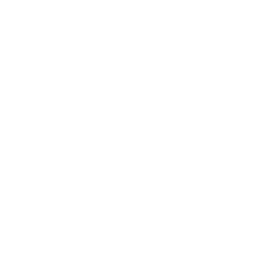
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Adverse Event Rate Analysis via Poisson Regression</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Pharmacovigilance &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Estimate treatment-specific adverse event (AE) rates in a simulated Phase III trial using **Poisson regression with a log-exposure offset**. Each patient contributes an AE count over a variable follow-up window, so the offset `log(exposure_py)` converts the model from counts to *rates per person-year*. The model adjusts for patient age and sex, and a Type 3 likelihood-ratio analysis tests each effect. Rate ratios versus placebo are obtained by exponentiating the model coefficients and their 95% confidence limits. Parameter estimates are captured via ODS OUTPUT and exported to CSV for downstream reporting and regulatory submission tables.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.AE_COUNTS | Patient-level AE counts with exposure time, 3 treatment arms | 100 |

The cohort is simulated at 100 patients with balanced 1:1:1 randomization across DRUG_HIGH, DRUG_LOW, and PLACEBO. Follow-up duration varies by patient (roughly 0.2 to 1.0 person-years), which is exactly the setting a log-exposure offset is designed for.

---

In [1]:
/* --------------------------------------------------------
   Generate patient-level AE count data with exposure time
   Pharma Phase III trial: 3 treatment arms, 100 patients
   -------------------------------------------------------- */
data work.ae_counts;
    call streaminit(42);
    array arm_list[3] $9 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    do patient_id = 1 to 100;
        /* --- balanced 1:1:1 treatment assignment --- */
        arm_idx = mod(patient_id - 1, 3) + 1;
        treatment = arm_list[arm_idx];

        /* --- demographics --- */
        age = int(rand('normal', 58, 11));
        if age < 18 then age = 18;
        if age > 85 then age = 85;
        sex = ifc(rand('uniform') > 0.47, 'F', 'M');

        /* --- exposure time in person-years (varying follow-up) --- */
        exposure_days = int(rand('uniform') * 300) + 60;
        exposure_py   = round(exposure_days / 365.25, 0.001);
        log_exposure  = log(exposure_py);

        /* --- AE count: Poisson rate scaled by exposure --- */
        if treatment = 'DRUG_HIGH' then base_rate = 6.0;
        else if treatment = 'DRUG_LOW' then base_rate = 3.2;
        else base_rate = 1.6;
        rate = base_rate * (1 + 0.012 * (age - 58));
        if sex = 'M' then rate = rate * 1.25;
        ae_count = rand('poisson', rate * exposure_py);

        output;
    end;
    drop arm_idx base_rate rate;
run;

NOTE: DATA work.ae_counts


NOTE: Wrote work.ae_counts (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline AE count distribution by treatment arm
   -------------------------------------------------------- */
proc means data=work.ae_counts n sum mean std min max;
    class treatment;
    var ae_count exposure_py;
run;

                                                  The MEANS Procedure

                                              Analysis Variable : AE_COUNT

        TREATMENT          N Obs            Sum           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------------------
        DRUG_HIGH             34    112.0000000      3.2941176      2.8975372      0.0000000     12.0000000
        DRUG_LOW              33     50.0000000      1.5151515      1.0037807      0.0000000      3.0000000
        PLACEBO               33     37.0000000      1.1212121      1.1390121      0.0000000      4.0000000
        ---------------------------------------------------------------------------------------------------

                                            Analysis Variable : EXPOSURE_PY

        TREATMENT          N Obs            Sum           Mean        Std Dev        Minimum        Maximum
        -----------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

NOTE: PROC SGPLOT data=work.ae_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


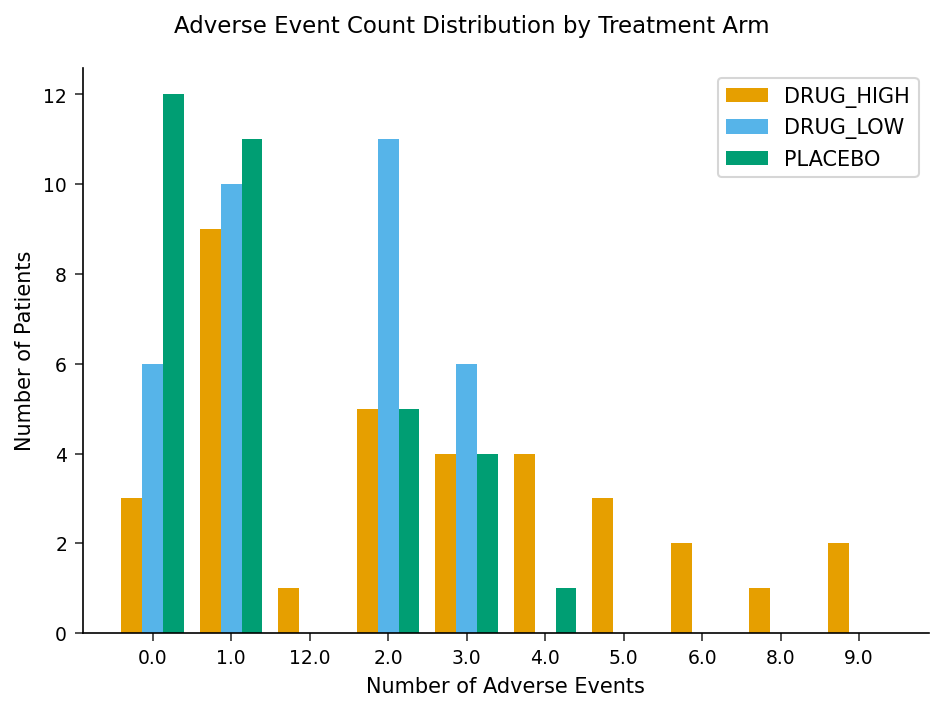

In [3]:
/* --------------------------------------------------------
   AE count distribution by treatment arm
   -------------------------------------------------------- */
proc sgplot data=work.ae_counts;
    vbar ae_count / group=treatment groupdisplay=cluster;
    xaxis label='Number of Adverse Events' integer;
    yaxis label='Number of Patients';
    title 'Adverse Event Count Distribution by Treatment Arm';
run;

---

        The GENMOD Procedure        
         Model Information          

Item                           Value
----------------------  ------------
Response Variable           AE_COUNT
Distribution                 poisson
Link Function                    log
Number of Observations           100
Offset Variable         LOG_EXPOSURE

      Analysis of Maximum Likelihood Parameter Estimates       

Parameter           Estimate  Std Error  Chi-Square  Pr > ChiSq
------------------  --------  ---------  ----------  ----------
(Intercept)          -0.3910     0.3832      1.0411      0.3076
TREATMENTDRUG_HIGH    1.1236     0.1913     34.4851      <.0001
TREATMENTDRUG_LOW     0.4713     0.2172      4.7101      0.0300
AGE                   0.0178     0.0060      8.9054      0.0028
SEXM                 -0.0043     0.1494      0.0008      0.9769

Criteria for Assessing Goodness of Fit

Criterion           Value
--------------  ---------
Deviance          98.4367
Log Likelihood  -152.8389
AIC    

NOTE: PROC GENMOD data=work.ae_counts

NOTE: PROC GENMOD using R wrapper
NOTE: 
NOTE: Response Variable: AE_COUNT
NOTE: Distribution: POISSON
NOTE: Link Function: LOG
NOTE: Number of Observations: 100
NOTE:   Model fitted successfully with 100 observations
NOTE: ODS plot written: genmod_residuals_vs_predicted.spec.json
NOTE: ODS plot written: genmod_residual_histogram_panel.spec.json
NOTE: ODS plot written: genmod_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: genmod_qq_plot.spec.json
NOTE: PROC GENMOD ODS Graphics generated.
NOTE: PROC GENMOD: Emitting ODS OUTPUT datasets (1 destination(s))
NOTE: DATA work.genmod_rr


NOTE: Read 5 rows from work.genmod_parms.
NOTE: Wrote work.genmod_rr (4 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


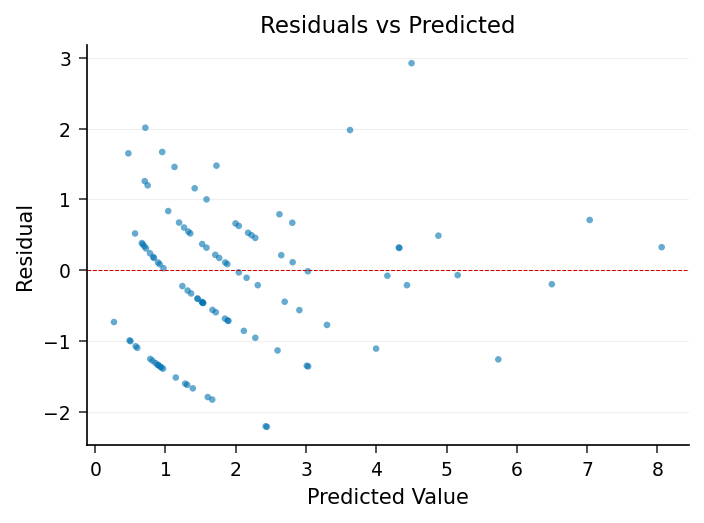

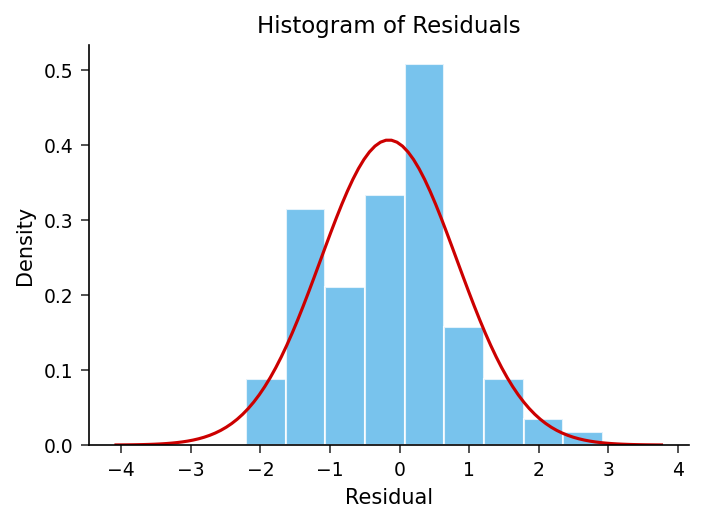

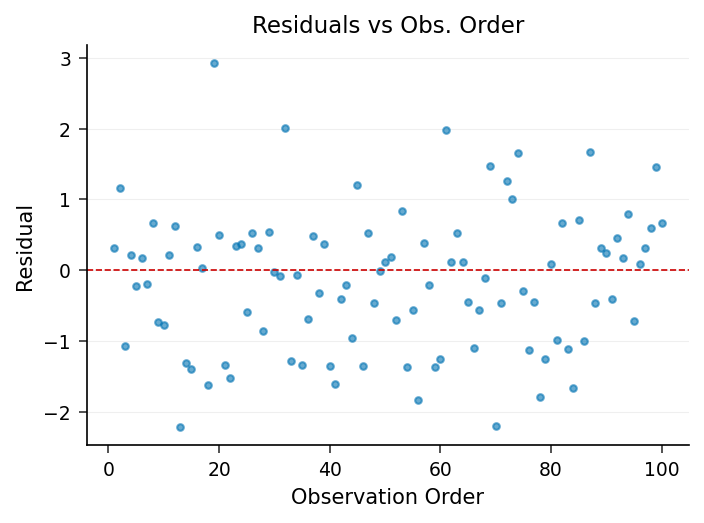

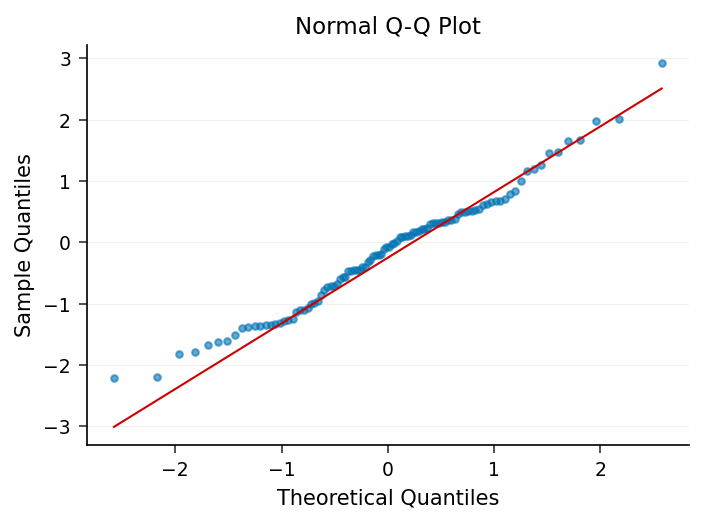

In [4]:
/* --------------------------------------------------------
   Poisson regression for adverse event rates
   OFFSET = log(exposure) -> coefficients are log rate ratios
   TYPE3 -> likelihood-ratio test for each effect
   -------------------------------------------------------- */
proc genmod data=work.ae_counts;
    class treatment (ref='PLACEBO') sex (ref='F');
    model ae_count = treatment age sex
        / dist=poisson
          link=log
          offset=log_exposure
          type3;
    ods output parameterestimates=work.genmod_parms;
run;

/* --------------------------------------------------------
   Convert log coefficients to rate ratios with 95% CI.
   exp(estimate) is the multiplicative effect on the AE rate
   per person-year, holding the other covariates fixed.
   -------------------------------------------------------- */
data work.genmod_rr;
    set work.genmod_parms;
    where parameter not in ('(Intercept)', 'Scale');
    rate_ratio  = exp(estimate);
    rr_lower_cl = exp(lowercl);
    rr_upper_cl = exp(uppercl);
    format rate_ratio rr_lower_cl rr_upper_cl 6.3;
    keep parameter estimate stderr probchisq
         rate_ratio rr_lower_cl rr_upper_cl;
run;

In [5]:
/* --------------------------------------------------------
   Review rate ratio estimates
   -------------------------------------------------------- */
proc print data=work.genmod_rr label noobs;
    label parameter   = 'Effect'
          rate_ratio  = 'Rate Ratio'
          rr_lower_cl = 'Lower 95% CL'
          rr_upper_cl = 'Upper 95% CL'
          probchisq   = 'Pr > ChiSq';
    var parameter rate_ratio rr_lower_cl rr_upper_cl probchisq;
    title 'Adverse Event Rate Ratios (vs. reference level)';
run;

                                    Adverse Event Rate Ratios (vs. reference level)                                     

            Effect  Rate Ratio  Lower 95% CL  Upper 95% CL    Pr > ChiSq
TREATMENTDRUG_HIGH       3.076         2.114         4.476  0.0000000043
TREATMENTDRUG_LOW        1.602         1.047         2.452  0.0299864864
AGE                      1.018         1.006         1.030  0.0028433634
SEXM                     0.996         0.743         1.334  0.9769198944



NOTE: PROC PRINT data=work.genmod_rr

NOTE: PROC PRINT completed: 4 observations printed, 5 variables


---

### Interpretation

Poisson regression with a log-exposure offset shows a clear, statistically significant dose-dependent effect on the adverse event rate. The Type 3 likelihood-ratio test for treatment is highly significant (χ² = 39.11 on 2 df, *p* < .0001).

- **High dose vs. placebo:** rate ratio **3.08** (95% CI 2.11 to 4.48), *p* < .0001 — patients on the high-dose arm experience roughly three times the AE rate per person-year of exposure.
- **Low dose vs. placebo:** rate ratio **1.60** (95% CI 1.05 to 2.45), *p* = 0.030 — a more moderate but still significant elevation, consistent with a dose-response gradient.
- **Age:** each additional year is associated with a **1.8%** increase in AE rate (rate ratio 1.018 per year, 95% CI 1.006 to 1.030; Type 3 *p* = 0.0028).
- **Sex:** after adjustment, the male-vs-female rate ratio is **0.996** (*p* = 0.977) — sex is **not** a significant predictor in this cohort.

The model fits with a deviance of 98.44 and AIC of 315.68 over 100 observations. The descriptive means corroborate the gradient: mean AE counts of 3.29 (high dose), 1.52 (low dose), and 1.12 (placebo). These results support dose-dependent safety monitoring and can inform benefit-risk assessment for the Data Safety Monitoring Board.

---

In [6]:
/* --------------------------------------------------------
   Export estimates for regulatory submission tables
   -------------------------------------------------------- */
proc export data=work.genmod_parms
    outfile='ae_rate_parameter_estimates.csv'
    dbms=csv replace;
run;

proc export data=work.genmod_rr
    outfile='ae_rate_ratios.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.genmod_parms outfile=ae_rate_parameter_estimates.csv

NOTE: Exported 5 rows to ae_rate_parameter_estimates.csv.
NOTE: PROC EXPORT data=work.genmod_rr outfile=ae_rate_ratios.csv

NOTE: Exported 4 rows to ae_rate_ratios.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>